# Notebook 03 — Data Preprocessing Pipeline
**Research**: Sentiment Analysis for Sinhala-English Code-Mixed Text  
**Student**: K.A. Ruwini Tharanga | 2020/ICT/31  

### Steps
1. Load & clean raw dataset  
2. Run LID tagging  
3. Stratified split (70/15/15)  
4. Class weight computation  
5. EDA visualisations for progress presentation

In [3]:
# ── Install dependencies (run once) ─────────────────────────────────────────
import subprocess, sys
pkgs = ['emoji', 'scikit-learn', 'matplotlib', 'seaborn', 'pandas', 'numpy']
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q'] + pkgs)

CompletedProcess(args=['c:\\Program Files\\Python314\\python.exe', '-m', 'pip', 'install', '-q', 'emoji', 'scikit-learn', 'matplotlib', 'seaborn', 'pandas', 'numpy'], returncode=0)

In [5]:
import os, sys
# Add project root to path so 'src' imports work
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import warnings
warnings.filterwarnings('ignore')

import unicodedata, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

# Font that supports Sinhala (fallback gracefully)
matplotlib.rcParams['font.family'] = ['Noto Sans Sinhala', 'DejaVu Sans', 'sans-serif']
plt.style.use('seaborn-v0_8-whitegrid')
print('Environment ready.')

Environment ready.


## 1. Load Raw Dataset

In [6]:
# ── Adjust this path if running from a different location ───────────────────
RAW_CSV = r'C:\Users\Ruwini Tharanga\Downloads\Sinhala_English_Code_Mixed_Sentiment_Analysis\data\raw\Dataset\singlish_mixed_sentiment_labeled.csv'
OUT_DIR = os.path.join(PROJECT_ROOT, 'data', 'processed')
os.makedirs(OUT_DIR, exist_ok=True)

LABEL_MAP = {'positive': 0, 'negative': 1, 'neutral': 2}
VALID_SENTIMENTS = set(LABEL_MAP.keys())
VALID_PLATFORMS  = {'youtube', 'facebook'}

raw = pd.read_csv(RAW_CSV, encoding='utf-8-sig')
print('Raw shape:', raw.shape)
print('Columns:', raw.columns.tolist())
raw.head(3)

Raw shape: (5967, 8)
Columns: ['id', 'text', 'sentiment', 'platform', 'source', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7']


,id,text,sentiment,platform,source,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,1,ඇත්තටම මාත් bachelor එකක් කරලා ඉන්නේ මේක මගේ p...,negative,youtube,x4jCX2iklw4,NaN,NaN,NaN
1,2,i watch your every video without skipping your...,positive,youtube,x4jCX2iklw4,NaN,NaN,NaN
2,3,ඔයා කොහොමද ඔය තැනට එනකම් මිනිස්සුන්ව සෙවකයන්ව ...,neutral,youtube,x4jCX2iklw4,NaN,NaN,NaN


In [7]:
# ── Remove junk columns and header-repeated rows ───────────────────────────
df = raw.loc[:, ~raw.columns.str.startswith('Unnamed')].copy()
df.columns = [c.strip().lower() for c in df.columns]

df = df[df['sentiment'].str.lower().isin(VALID_SENTIMENTS)]
df = df[df['platform'].str.lower().isin(VALID_PLATFORMS)]
df['sentiment'] = df['sentiment'].str.lower().str.strip()
df['platform']  = df['platform'].str.lower().str.strip()
df = df.dropna(subset=['text'])
df = df[df['text'].str.strip() != '']
df = df.reset_index(drop=True)

print(f'Clean rows: {len(df)}')
print('Sentiment distribution:')
print(df['sentiment'].value_counts())
print('\nPlatform distribution:')
print(df['platform'].value_counts())

Clean rows: 5958
Sentiment distribution:
sentiment
positive    2152
neutral     2032
negative    1774
Name: count, dtype: int64

Platform distribution:
platform
youtube     4015
facebook    1943
Name: count, dtype: int64


## 2. Preprocessing Pipeline

In [8]:
# ── Sinhala normalisation dictionary ───────────────────────────────────────
SINHALA_NORM = {
    'හරිිිම': 'හරිම', 'හරිීීම': 'හරිම', 'හරිිම': 'හරිම',
    'ගොඩාක්ක': 'ගොඩාක්', 'ගොඩාක': 'ගොඩාක්', 'ගොඩක්ක': 'ගොඩාක්', 'ගොඩක': 'ගොඩාක්',
    'නෑෑ': 'නෑ', 'නෑෑෑ': 'නෑ', 'නෙවෙයි': 'නෙවේ', 'නෙවෙ': 'නෙවේ',
    'ආස්': 'ආසා', 'ආස': 'ආසා',
    'ඔව්ව': 'ඔව්', 'නෑනෑ': 'නෑ',
}
TRANSLIT_NORM = {
    'hariiima': 'harima', 'hariima': 'harima',
    'godaak': 'godak', 'lasanai': 'lassanai',
}

def normalize_sinhala(text):
    for variant, canon in SINHALA_NORM.items():
        text = text.replace(variant, canon)
    words = text.split()
    return ' '.join(TRANSLIT_NORM.get(w.lower(), w) for w in words)

# ── Regex patterns ─────────────────────────────────────────────────────────
URL_RE      = re.compile(r'http[s]?://\S+|www\.\S+', re.I)
MENTION_RE  = re.compile(r'@\w+')
HASHTAG_RE  = re.compile(r'#\w+')
HTML_RE     = re.compile(r'<[^>]+>|&[a-z]+;|&#\d+;')
REPEAT_RE   = re.compile(r'(.)\1{2,}')
WS_RE       = re.compile(r'\s+')

try:
    import emoji as emoji_lib
    _EMOJI_OK = True
except ImportError:
    _EMOJI_OK = False

def clean_text(text, demojize=False):
    if not isinstance(text, str) or not text.strip():
        return ''
    text = unicodedata.normalize('NFC', text)
    text = HTML_RE.sub(' ', text)
    text = URL_RE.sub(' ', text)
    text = MENTION_RE.sub(' ', text)
    text = HASHTAG_RE.sub(' ', text)
    text = REPEAT_RE.sub(r'\1\1', text)
    if demojize and _EMOJI_OK:
        text = emoji_lib.demojize(text, delimiters=(' :', ': '))
    text = normalize_sinhala(text)
    return WS_RE.sub(' ', text).strip()

# Quick test
samples = [
    'ඇත්තතෙන්ම මේක superrrrr 😍 https://t.co/xyz @user #srilanka',
    'hariiima boring ekak.. nehe me',
    'ගොඩාක් ලස්සනෙ place ekak',
]
for s in samples:
    print(repr(clean_text(s)))

'ඇත්තතෙන්ම මේක superr 😍'
'harima boring ekak.. nehe me'
'ගොඩාක්් ලස්සනෙ place ekak'


In [9]:
# ── LID Tagger ─────────────────────────────────────────────────────────────
SINHALA_LO, SINHALA_HI = 0x0D80, 0x0DFF
LATIN_RE   = re.compile(r'[A-Za-z]')
DIGIT_RE   = re.compile(r'^\d+([.,]\d+)?$')
EMOJI_RE   = re.compile(
    '[\U0001F600-\U0001F64F\U0001F300-\U0001F5FF'
    '\U0001F680-\U0001F6FF\U0001F1E0-\U0001F1FF'
    '\U00002702-\U000027B0\U000024C2-\U0001F251]+',
    re.UNICODE
)

def tag_token(tok):
    if EMOJI_RE.fullmatch(tok):  return 'EM'
    if DIGIT_RE.match(tok):      return 'NUM'
    if any(SINHALA_LO <= ord(c) <= SINHALA_HI for c in tok): return 'SI'
    if LATIN_RE.search(tok):     return 'EN'
    return 'PUN'

def compute_cmi(tags):
    lang = [t for t in tags if t in ('SI', 'EN')]
    if len(lang) < 2: return 0.0
    majority = max(lang.count('SI'), lang.count('EN'))
    return round(1 - majority / len(lang), 4)

def tag_sentence(text):
    tokens = text.split()
    tags   = [tag_token(t) for t in tokens]
    return {
        'tagged_text':   ' '.join(f'{t}[{g}]' for t, g in zip(tokens, tags)),
        'lid_sequence':  ' '.join(tags),
        'n_sinhala':     tags.count('SI'),
        'n_english':     tags.count('EN'),
        'n_emoji':       tags.count('EM'),
        'cmi':           compute_cmi(tags),
        'is_code_mixed': 'SI' in tags and 'EN' in tags,
    }

# Test
print(tag_sentence('harima boring ekak'))
print(tag_sentence('ඇත්තටම godak lassanai nehe'))

{'tagged_text': 'harima[EN] boring[EN] ekak[EN]', 'lid_sequence': 'EN EN EN', 'n_sinhala': 0, 'n_english': 3, 'n_emoji': 0, 'cmi': 0.0, 'is_code_mixed': False}
{'tagged_text': 'ඇත්තටම[SI] godak[EN] lassanai[EN] nehe[EN]', 'lid_sequence': 'SI EN EN EN', 'n_sinhala': 1, 'n_english': 3, 'n_emoji': 0, 'cmi': 0.25, 'is_code_mixed': True}


In [10]:
# ── Apply to full dataset ──────────────────────────────────────────────────
print('Cleaning texts...')
df['cleaned_text'] = df['text'].apply(clean_text)
df = df[df['cleaned_text'].str.strip() != ''].reset_index(drop=True)
print(f'After cleaning: {len(df)} rows')

print('Running LID tagging...')
lid_results = df['cleaned_text'].apply(tag_sentence)
lid_df = pd.json_normalize(lid_results)

for col in ['tagged_text', 'lid_sequence', 'n_sinhala', 'n_english', 'n_emoji', 'cmi', 'is_code_mixed']:
    df[col] = lid_df[col].values

df['label'] = df['sentiment'].map(LABEL_MAP)
print('Done. Sample:')
df[['text', 'cleaned_text', 'tagged_text', 'sentiment', 'cmi', 'is_code_mixed']].head(100)

Cleaning texts...
After cleaning: 5958 rows
Running LID tagging...
Done. Sample:


,text,cleaned_text,tagged_text,sentiment,cmi,is_code_mixed
0,ඇත්තටම මාත් bachelor එකක් කරලා ඉන්නේ මේක මගේ p...,ඇත්තටම මාත් bachelor එකක් කරලා ඉන්නේ මේක මගේ p...,ඇත්තටම[SI] මාත්[SI] bachelor[EN] එකක්[SI] කරලා...,negative,0.0645,True
1,i watch your every video without skipping your...,i watch your every video without skipping your...,i[EN] watch[EN] your[EN] every[EN] video[EN] w...,positive,0.0000,False
2,ඔයා කොහොමද ඔය තැනට එනකම් මිනිස්සුන්ව සෙවකයන්ව ...,ඔයා කොහොමද ඔය තැනට එනකම් මිනිස්සුන්ව සෙවකයන්ව ...,ඔයා[SI] කොහොමද[SI] ඔය[SI] තැනට[SI] එනකම්[SI] ම...,neutral,0.0833,True
3,oya thanikarama karala thiyenne gap fill karap...,oya thanikarama karala thiyenne gap fill karap...,oya[EN] thanikarama[EN] karala[EN] thiyenne[EN...,negative,0.0000,False
4,අපිට factory එකක් පෙන්නන්න carnage මහන තැන,අපිට factory එකක් පෙන්නන්න carnage මහන තැන,අපිට[SI] factory[EN] එකක්[SI] පෙන්නන්න[SI] car...,neutral,0.2857,True
...,...,...,...,...,...,...
95,thnkz scipioඅදත් ලස්සන පාඩමක්,thnkz scipioඅදත් ලස්සන පාඩමක්,thnkz[EN] scipioඅදත්[SI] ලස්සන[SI] පාඩමක්[SI],neutral,0.2500,True
96,love you scipio oyawa dakina akath සතුටක්,love you scipio oyawa dakina akath සතුටක්,love[EN] you[EN] scipio[EN] oyawa[EN] dakina[E...,positive,0.1429,True
97,මගේ ජීවිතේ මට ලැබෙන omens ගැන මම stuck වුණ ගොඩ...,මගේ ජීවිතේ මට ලැබෙන omens ගැන මම stuck වුණ ගොඩ...,මගේ[SI] ජීවිතේ[SI] මට[SI] ලැබෙන[SI] omens[EN] ...,positive,0.4828,True
98,aiye mn oyage videos 23k withara thamai balala...,aiye mn oyage videos 23k withara thamai balala...,aiye[EN] mn[EN] oyage[EN] videos[EN] 23k[EN] w...,neutral,0.0000,False


## 3. Stratified Split (70 / 15 / 15)

In [11]:
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df['label'], random_state=42)
val_df, test_df   = train_test_split(temp_df, test_size=0.50, stratify=temp_df['label'], random_state=42)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f'Train : {len(train_df)} rows')
print(f'Val   : {len(val_df)} rows')
print(f'Test  : {len(test_df)} rows')
print('\nTrain sentiment dist:')
print(train_df['sentiment'].value_counts())

Train : 4170 rows
Val   : 894 rows
Test  : 894 rows

Train sentiment dist:
sentiment
positive    1506
neutral     1422
negative    1242
Name: count, dtype: int64


## 4. Class Weight Computation

In [12]:
classes = np.array([0, 1, 2])
weights = compute_class_weight('balanced', classes=classes, y=train_df['label'].values)
class_weights = {int(c): round(float(w), 4) for c, w in zip(classes, weights)}
print('Class weights (0=positive, 1=negative, 2=neutral):')
print(class_weights)
print('\nUse in PyTorch: torch.tensor(list(class_weights.values()), dtype=torch.float).to(device)')

Class weights (0=positive, 1=negative, 2=neutral):
{0: 0.923, 1: 1.1192, 2: 0.9775}

Use in PyTorch: torch.tensor(list(class_weights.values()), dtype=torch.float).to(device)


## 5. Save Processed Splits

In [13]:
SAVE_COLS = ['id', 'text', 'cleaned_text', 'tagged_text', 'lid_sequence',
             'sentiment', 'label', 'platform', 'source',
             'n_sinhala', 'n_english', 'n_emoji', 'cmi', 'is_code_mixed']

for name, split in [('train', train_df), ('val', val_df), ('test', test_df)]:
    cols = [c for c in SAVE_COLS if c in split.columns]
    path = os.path.join(OUT_DIR, f'{name}.csv')
    split[cols].to_csv(path, index=False, encoding='utf-8-sig')
    print(f'Saved {name}.csv → {len(split)} rows')

# Save class weights
with open(os.path.join(OUT_DIR, 'class_weights.txt'), 'w') as f:
    f.write('# class_weights for CrossEntropyLoss\n')
    f.write('# 0=positive  1=negative  2=neutral\n')
    for cls, w in class_weights.items():
        lname = {0:'positive',1:'negative',2:'neutral'}[cls]
        f.write(f'{cls} ({lname}): {w}\n')
print('Saved class_weights.txt')

Saved train.csv → 4170 rows
Saved val.csv → 894 rows
Saved test.csv → 894 rows
Saved class_weights.txt


## 6. EDA Visualisations for Progress Presentation

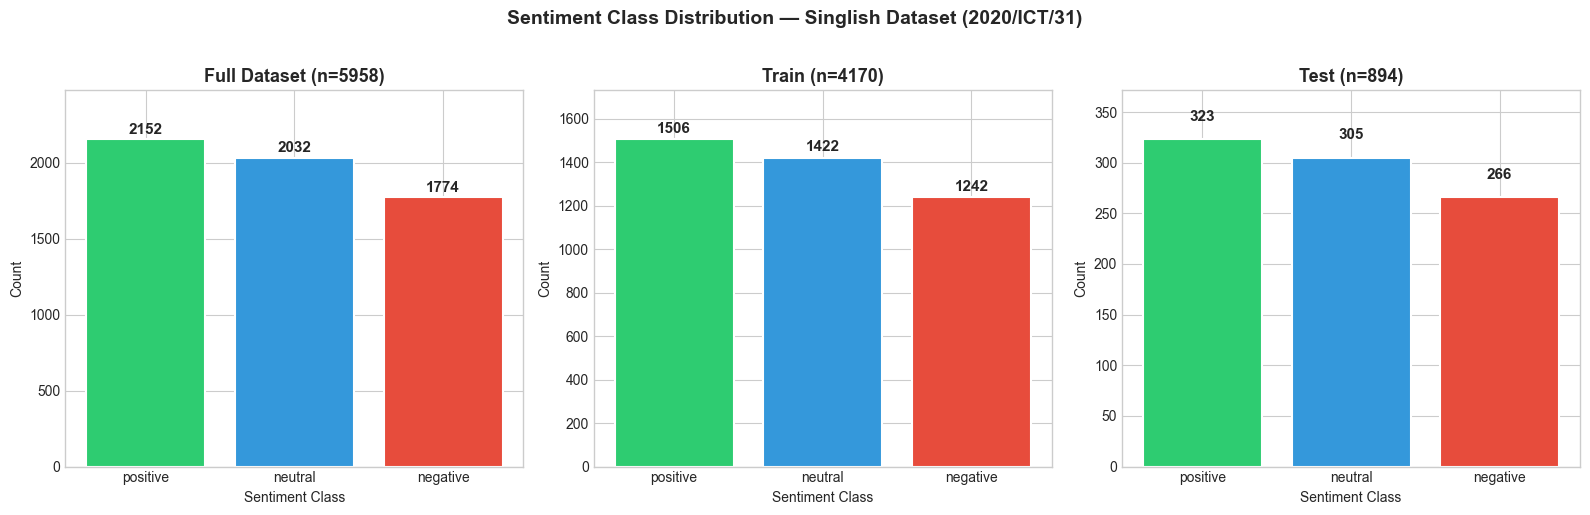

Saved fig1_sentiment_distribution.png


In [14]:
FIG_DIR = os.path.join(PROJECT_ROOT, 'notebooks', 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

# ── Figure 1: Sentiment class distribution ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
palette = {'positive': '#2ecc71', 'negative': '#e74c3c', 'neutral': '#3498db'}

for ax, (name, split) in zip(axes, [('Full Dataset', df), ('Train', train_df), ('Test', test_df)]):
    counts = split['sentiment'].value_counts()
    colors = [palette[c] for c in counts.index]
    bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.5)
    for bar, count in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
                str(count), ha='center', va='bottom', fontweight='bold', fontsize=11)
    ax.set_title(f'{name} (n={len(split)})', fontsize=13, fontweight='bold')
    ax.set_xlabel('Sentiment Class')
    ax.set_ylabel('Count')
    ax.set_ylim(0, counts.max() * 1.15)

plt.suptitle('Sentiment Class Distribution — Singlish Dataset (2020/ICT/31)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig1_sentiment_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig1_sentiment_distribution.png')

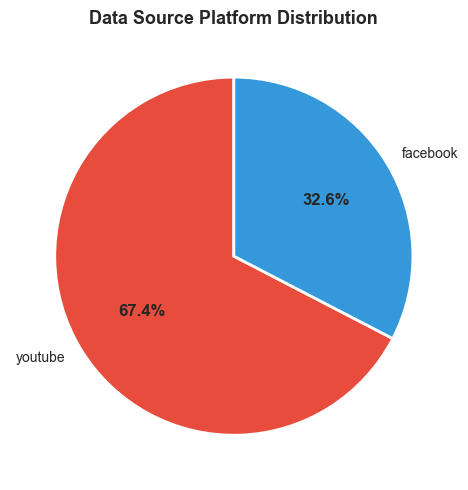

Saved fig2_platform_distribution.png


In [15]:
# ── Figure 2: Platform distribution ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
platform_counts = df['platform'].value_counts()
wedges, texts, autotexts = ax.pie(
    platform_counts.values,
    labels=platform_counts.index,
    autopct='%1.1f%%',
    colors=['#e74c3c', '#3498db'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
ax.set_title('Data Source Platform Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig2_platform_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig2_platform_distribution.png')

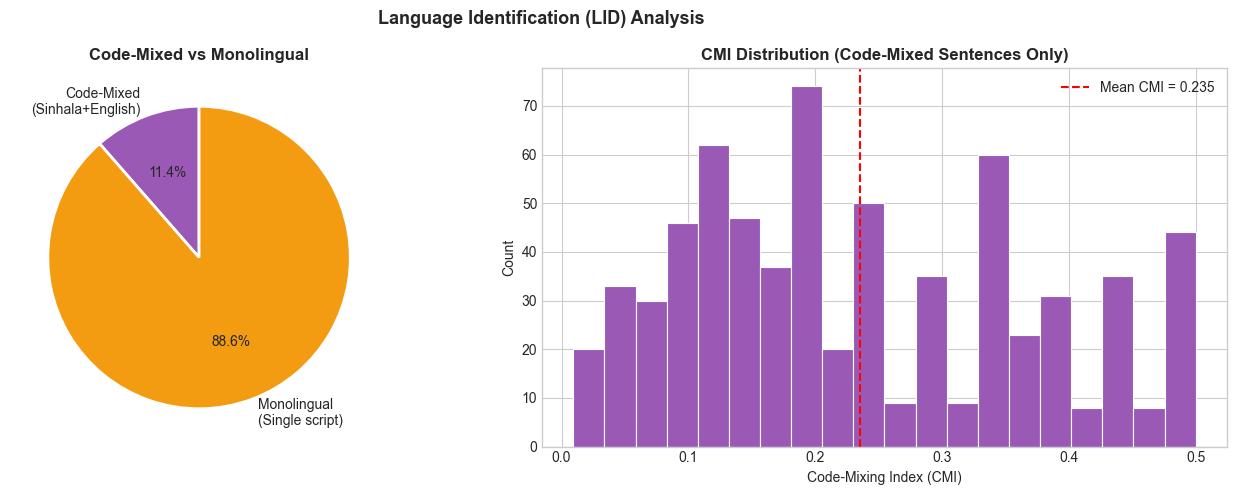

Saved fig3_lid_analysis.png


In [16]:
# ── Figure 3: LID Tag Analysis ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Code-Mixed vs Monolingual
cm_counts = df['is_code_mixed'].value_counts()
labels_pie = ['Code-Mixed\n(Sinhala+English)', 'Monolingual\n(Single script)']
axes[0].pie(
    [cm_counts.get(True, 0), cm_counts.get(False, 0)],
    labels=labels_pie,
    autopct='%1.1f%%',
    colors=['#9b59b6', '#f39c12'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Code-Mixed vs Monolingual', fontsize=12, fontweight='bold')

# CMI distribution
code_mixed_only = df[df['is_code_mixed']]
axes[1].hist(code_mixed_only['cmi'], bins=20, color='#9b59b6', edgecolor='white', linewidth=0.8)
axes[1].axvline(code_mixed_only['cmi'].mean(), color='red', linestyle='--',
                label=f'Mean CMI = {code_mixed_only["cmi"].mean():.3f}')
axes[1].set_xlabel('Code-Mixing Index (CMI)')
axes[1].set_ylabel('Count')
axes[1].set_title('CMI Distribution (Code-Mixed Sentences Only)', fontsize=12, fontweight='bold')
axes[1].legend()

plt.suptitle('Language Identification (LID) Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig3_lid_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig3_lid_analysis.png')

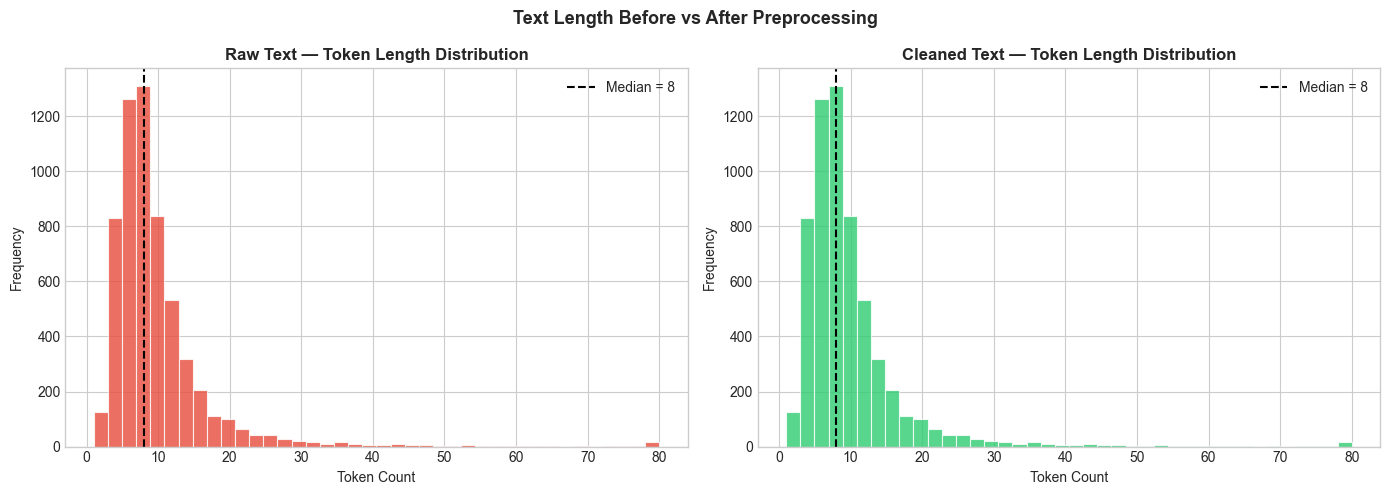

In [17]:
# ── Figure 4: Preprocessing before/after text length ──────────────────────
df['raw_len']     = df['text'].str.split().str.len()
df['cleaned_len'] = df['cleaned_text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['raw_len'].clip(upper=80), bins=40, color='#e74c3c', edgecolor='white', linewidth=0.8, alpha=0.8)
axes[0].set_title('Raw Text — Token Length Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Token Count')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['raw_len'].median(), color='black', linestyle='--',
                label=f'Median = {df["raw_len"].median():.0f}')
axes[0].legend()

axes[1].hist(df['cleaned_len'].clip(upper=80), bins=40, color='#2ecc71', edgecolor='white', linewidth=0.8, alpha=0.8)
axes[1].set_title('Cleaned Text — Token Length Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Token Count')
axes[1].set_ylabel('Frequency')
axes[1].axvline(df['cleaned_len'].median(), color='black', linestyle='--',
                label=f'Median = {df["cleaned_len"].median():.0f}')
axes[1].legend()

plt.suptitle('Text Length Before vs After Preprocessing', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig4_text_length.png'), dpi=150, bbox_inches='tight')
plt.show()

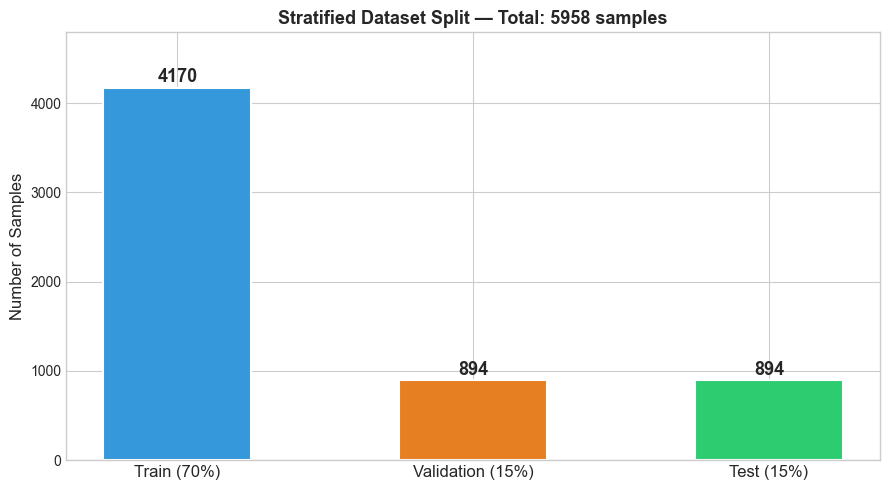

Saved fig5_dataset_split.png


In [18]:
# ── Figure 5: Dataset split overview ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
split_names  = ['Train (70%)', 'Validation (15%)', 'Test (15%)']
split_totals = [len(train_df), len(val_df), len(test_df)]
colors       = ['#3498db', '#e67e22', '#2ecc71']

x = range(len(split_names))
bars = ax.bar(x, split_totals, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
for bar, total in zip(bars, split_totals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            str(total), ha='center', va='bottom', fontweight='bold', fontsize=13)

ax.set_xticks(list(x))
ax.set_xticklabels(split_names, fontsize=12)
ax.set_ylabel('Number of Samples', fontsize=12)
ax.set_title(f'Stratified Dataset Split — Total: {len(df)} samples', fontsize=13, fontweight='bold')
ax.set_ylim(0, max(split_totals) * 1.15)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig5_dataset_split.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig5_dataset_split.png')

In [19]:
# ── Summary Table for Presentation ─────────────────────────────────────────
print('='*60)
print('   PREPROCESSING SUMMARY — 2020/ICT/31')
print('='*60)
print(f'  Raw collected samples     : {len(raw):,}')
print(f'  After cleaning/filtering  : {len(df):,}')
print(f'  Code-mixed sentences      : {df["is_code_mixed"].sum():,} ({df["is_code_mixed"].mean()*100:.1f}%)')
print(f'  Mean CMI (code-mixed only): {df[df["is_code_mixed"].astype(bool)]["cmi"].mean():.3f}')
print(f'  Avg Sinhala tokens/sent   : {df["n_sinhala"].mean():.1f}')
print(f'  Avg English tokens/sent   : {df["n_english"].mean():.1f}')
print(f'  Avg text length (tokens)  : {df["cleaned_len"].mean():.1f}')
print()
print('  Class distribution (full):')
for sent, cnt in df['sentiment'].value_counts().items():
    print(f'    {sent:<12}: {cnt:,} ({cnt/len(df)*100:.1f}%)')
print()
print('  Class weights for training:')
for cls, w in class_weights.items():
    lname = {0:'positive',1:'negative',2:'neutral'}[cls]
    print(f'    {lname:<12}: {w}')
print()
print('  Train/Val/Test split:')
print(f'    Train : {len(train_df):,}')
print(f'    Val   : {len(val_df):,}')
print(f'    Test  : {len(test_df):,}')
print('='*60)

   PREPROCESSING SUMMARY — 2020/ICT/31
  Raw collected samples     : 5,967
  After cleaning/filtering  : 5,958
  Code-mixed sentences      : 681 (11.4%)
  Mean CMI (code-mixed only): 0.235
  Avg Sinhala tokens/sent   : 1.3
  Avg English tokens/sent   : 8.2
  Avg text length (tokens)  : 9.5

  Class distribution (full):
    positive    : 2,152 (36.1%)
    neutral     : 2,032 (34.1%)
    negative    : 1,774 (29.8%)

  Class weights for training:
    positive    : 0.923
    negative    : 1.1192
    neutral     : 0.9775

  Train/Val/Test split:
    Train : 4,170
    Val   : 894
    Test  : 894
